# Mechanics External Impulse Comparison

This notebook compares position and velocity traces from the different tools against the analytical solution for the external impulse benchmark.

Each code cell below now has a single purpose:
- import dependencies
- define file locations
- define plotting styles
- load and normalize each tool's output
- plot the full comparisons
- plot the subsets that currently look inconsistent
- record follow-up checks on units, force, and velocity

In [23]:
# Imports used for loading benchmark outputs and plotting comparisons.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


## Data Locations

This cell defines where each tool stores its external impulse benchmark results, plus the directory containing the analytical reference solution.

In [24]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'mechanics_externalImpulse' / 'results_3s_force'
CHASTE_DIR = ROOT / 'Chaste' / 'MechanicsWithFriction'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'external_impulse'
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'mechanics_external_impulse' / 'dt_0.001'
TISIM_DIR = ROOT / 'Tisim' / 'mechanics_external_impulse'
ANALYTICAL_DIR = ROOT / 'analytical_solutions' / 'mechanics'
PLOTS_DIR = ROOT / 'ResultAnalysis' / 'plots'


## Plot Styling

This cell assigns a stable color and linestyle to each tool so the position and velocity plots are consistent across the notebook.

In [25]:
COLORS = {
    'PhysiCell': '#4daf4a',
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'TiSim': '#984ea3',
    'CompuTiX': '#fd2a2a',
    'Analytical Solution': 'black',
}

LINESTYLES = {
    'BioDynaMo': 'None',
    'Chaste': '-',
    'CompuTiX (explicit)': ':',
    'CompuTiX (implicit)': '--',
    'PhysiCell': '--',
    'TiSim': '-',
    'Analytical Solution': '-.',
}


## Load And Normalize Outputs

This cell reads each tool's exported benchmark data, extracts the x-position and x-velocity components, and converts units where needed so every series is compared in seconds, micrometers, and micrometers per second.

In [26]:
# BioDynaMo: parse x-position and x-velocity from comma-separated vector columns.
bdm_pos_raw = pd.read_csv(BIODYNAMO_DIR / 'positions.csv', sep='\t', header=None, names=['time', 'xyz'])
bdm_pos_raw['x'] = bdm_pos_raw['xyz'].str.strip().str.split(',').str[0].astype(float)
bdm_spd_raw = pd.read_csv(BIODYNAMO_DIR / 'speeds.csv', sep='\t', header=None, names=['time', 'vxyz'])
bdm_spd_raw['vx'] = bdm_spd_raw['vxyz'].str.strip().str.split(',').str[0].astype(float)
bdm_time = bdm_pos_raw['time'].values
bdm_x = bdm_pos_raw['x'].values
bdm_vx = bdm_spd_raw['vx'].values

# Chaste: split packed vector columns and keep the x components used in this benchmark.
chaste_loc = pd.read_csv(CHASTE_DIR / 'node_locations.dat', sep='\t', header=None, names=['time', 'xy'])
chaste_loc['x'] = chaste_loc['xy'].str.strip().str.split().str[0].astype(float)
chaste_vel = pd.read_csv(CHASTE_DIR / 'cell_velocities.dat', sep='\t', header=None, names=['time', 'vals'])
vel_cols = chaste_vel['vals'].str.strip().str.split(expand=True).astype(float)
chaste_time = chaste_loc['time'].values
chaste_x = chaste_loc['x'].values
chaste_vx = vel_cols[3].values

# CompuTiX: load YAML outputs and convert SI units to micrometers and micrometers per second.
with open(COMPUTIX_DIR / 'impulse_benchmark.yaml') as f:
    ctix = yaml.safe_load(f)

ctix_time = np.array(ctix['t']['values'])
ctix_x_imp = np.array(ctix['x_implicit']['values']) * 1e6
ctix_v_imp = np.array(ctix['v_implicit']['values']) * 1e6
ctix_x_exp = np.array(ctix['x_explicit']['values']) * 1e6
ctix_v_exp = np.array(ctix['v_explicit']['values']) * 1e6

# PhysiCell: convert time from minutes to seconds and velocity from micrometers per minute to micrometers per second.
pc_df = pd.read_csv(PHYSICELL_DIR / 'physicell_mechanics_external_impulse_data.csv')
pc_time = pc_df['dt'].values * 60
pc_x = pc_df['x'].values
pc_vx = pc_df['mvx'].values / 60

# TiSim: read the already separated position and velocity columns.
tisim_df = pd.read_csv(TISIM_DIR / 'mechanics_external_impulse.csv')
tisim_time = tisim_df['time'].values
tisim_x = tisim_df['position'].values
tisim_vx = tisim_df['velocity'].values

# Analytical solution: load the reference trace used for comparison.
analytical_df = pd.read_csv(ANALYTICAL_DIR / 'analytical_values.csv')


## Position Comparison

This cell plots all tools together against the analytical position trace and saves the figure for later reporting.

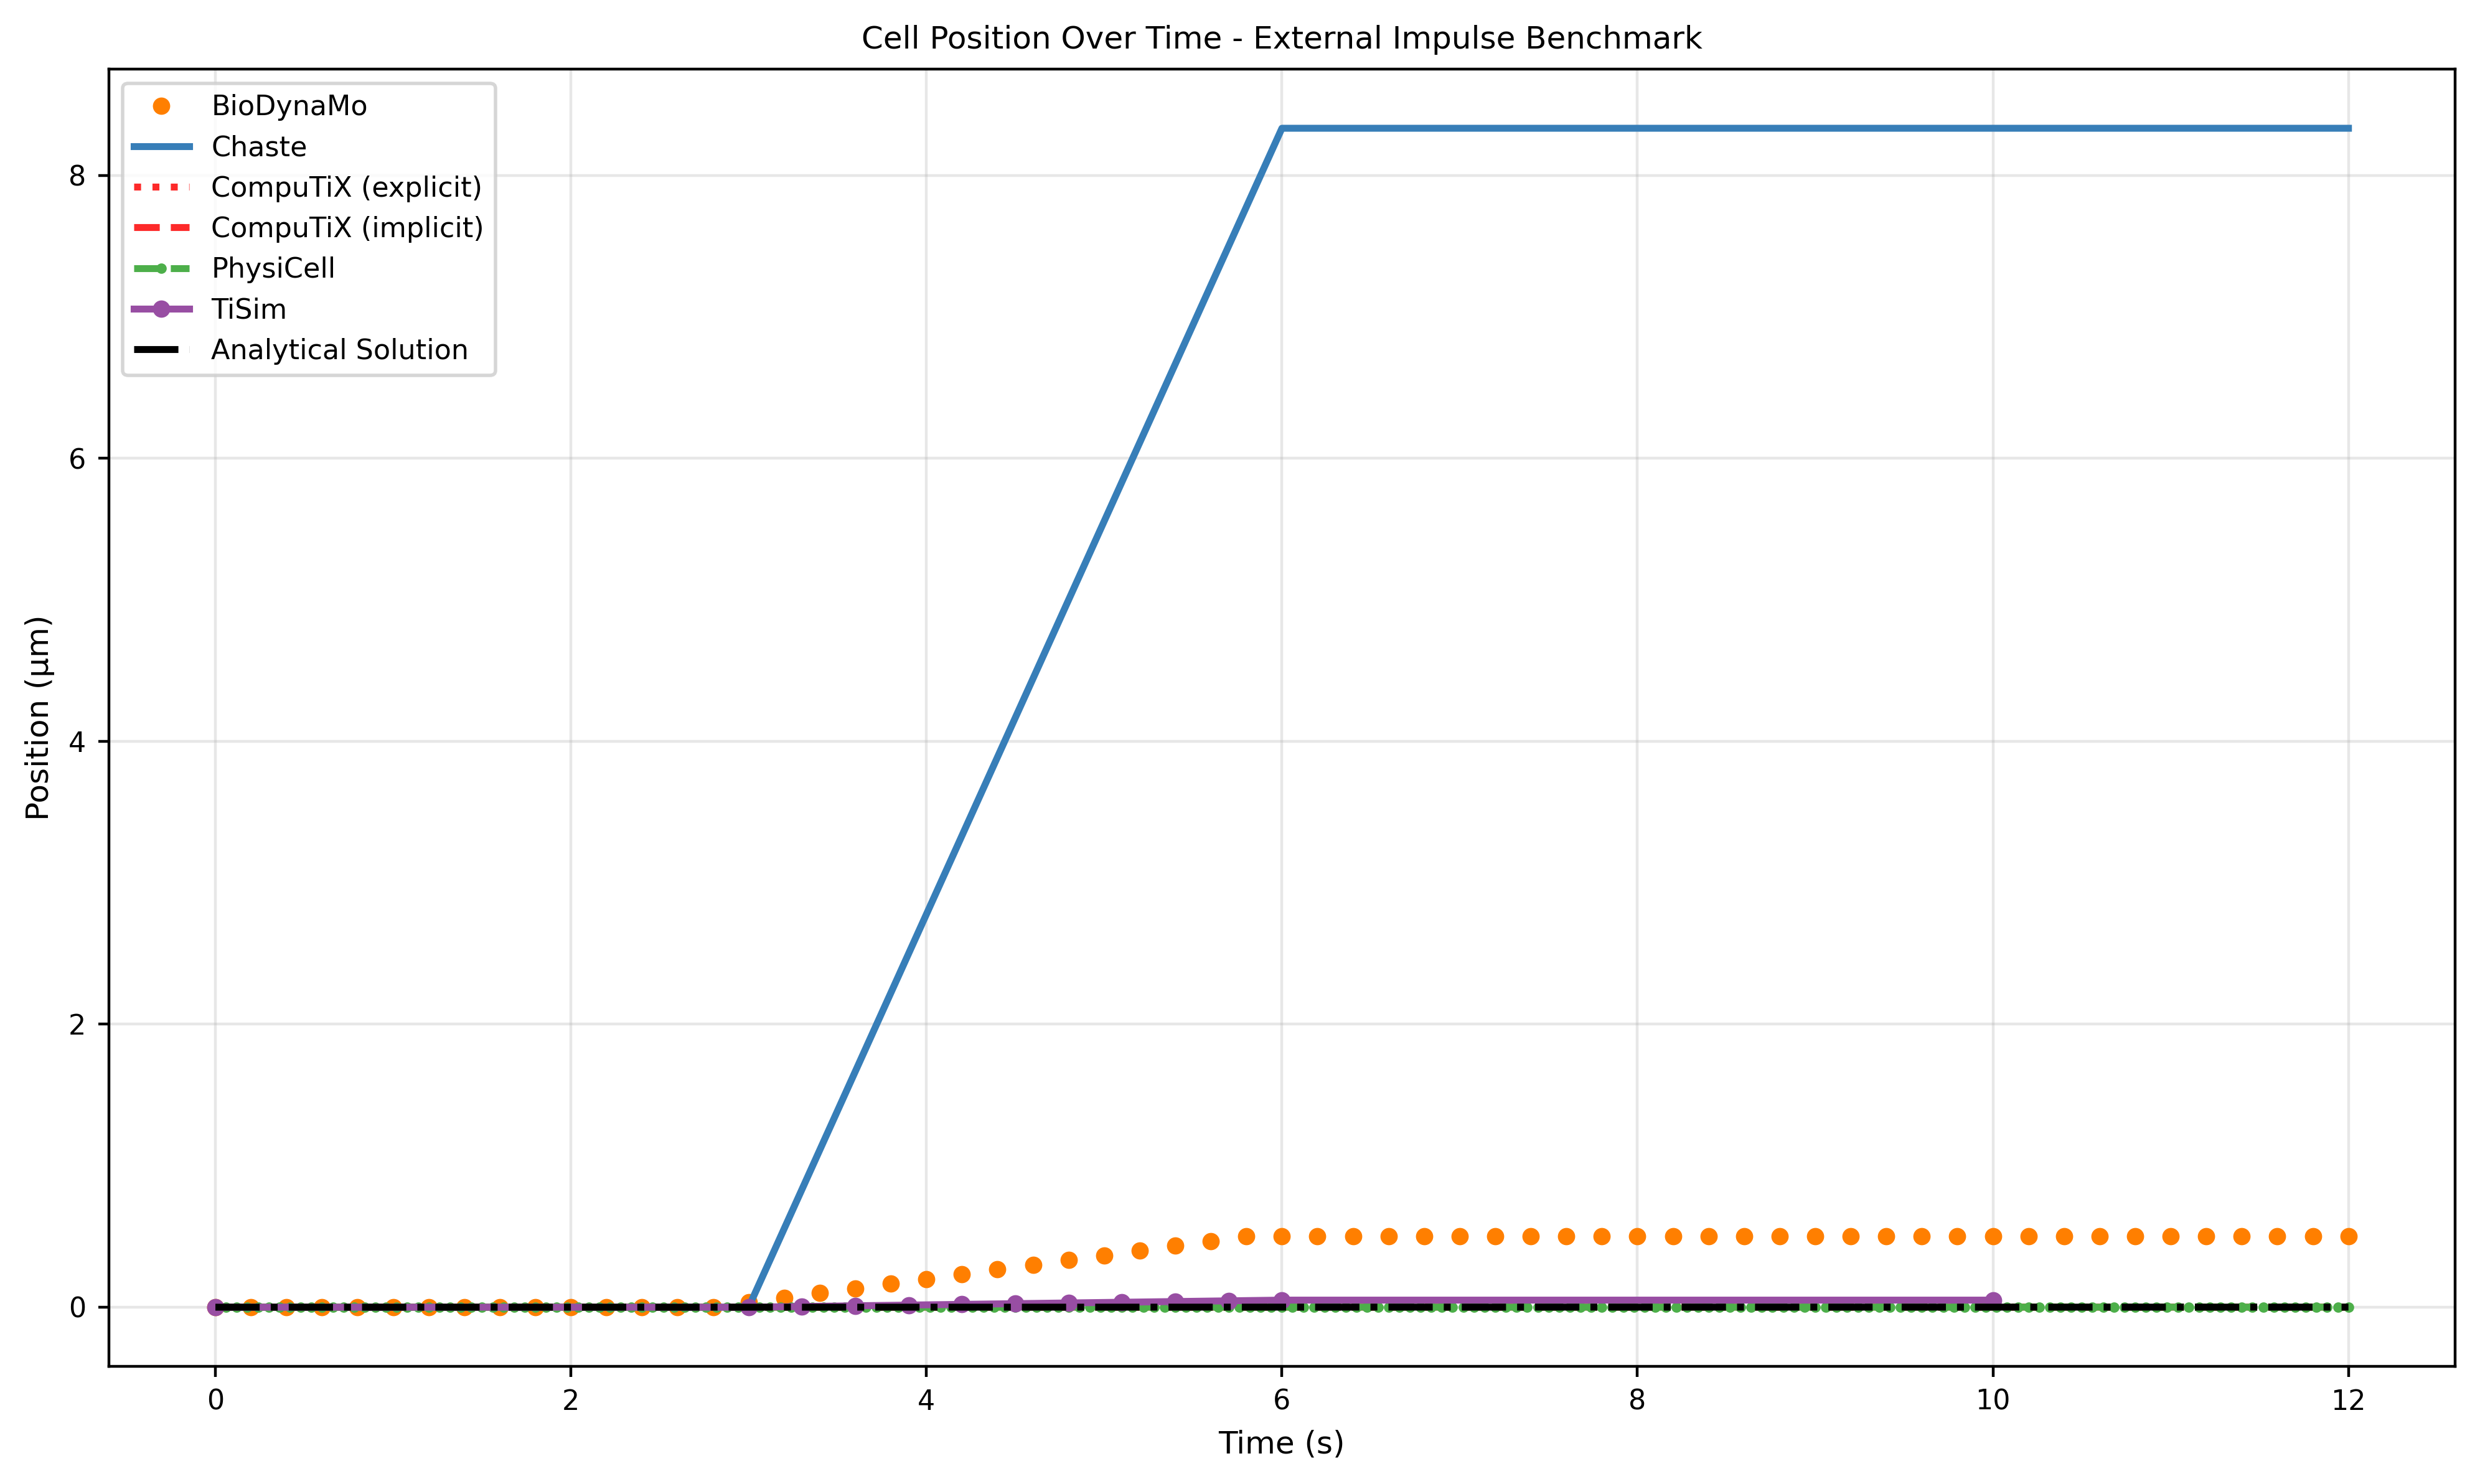

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time, bdm_x, label='BioDynaMo', lw=2, marker='o', linestyle=LINESTYLES['BioDynaMo'], ms=4, color=COLORS['BioDynaMo'])
ax.plot(chaste_time, chaste_x, label='Chaste', lw=2, linestyle=LINESTYLES['Chaste'], color=COLORS['Chaste'])
ax.plot(ctix_time, ctix_x_exp, label='CompuTiX (explicit)', lw=2, linestyle=LINESTYLES['CompuTiX (explicit)'], color=COLORS['CompuTiX'])
ax.plot(ctix_time, ctix_x_imp, label='CompuTiX (implicit)', lw=2, linestyle=LINESTYLES['CompuTiX (implicit)'], color=COLORS['CompuTiX'])
ax.plot(pc_time, pc_x, label='PhysiCell', lw=2, marker='.', linestyle=LINESTYLES['PhysiCell'], ms=4, color=COLORS['PhysiCell'])
ax.plot(tisim_time, tisim_x, label='TiSim', lw=2, marker='o', linestyle=LINESTYLES['TiSim'], ms=4, color=COLORS['TiSim'])
ax.plot(analytical_df['time_s'], analytical_df['distance_um'], label='Analytical Solution', lw=2, linestyle=LINESTYLES['Analytical Solution'], color=COLORS['Analytical Solution'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (µm)')
ax.set_title('Cell Position Over Time - External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mechanics_external_impulse_position.png', dpi=150)
plt.show()


## Position Focus Plot

This cell keeps only the tools whose position traces currently deserve closer inspection, without relying on commented-out plotting lines.

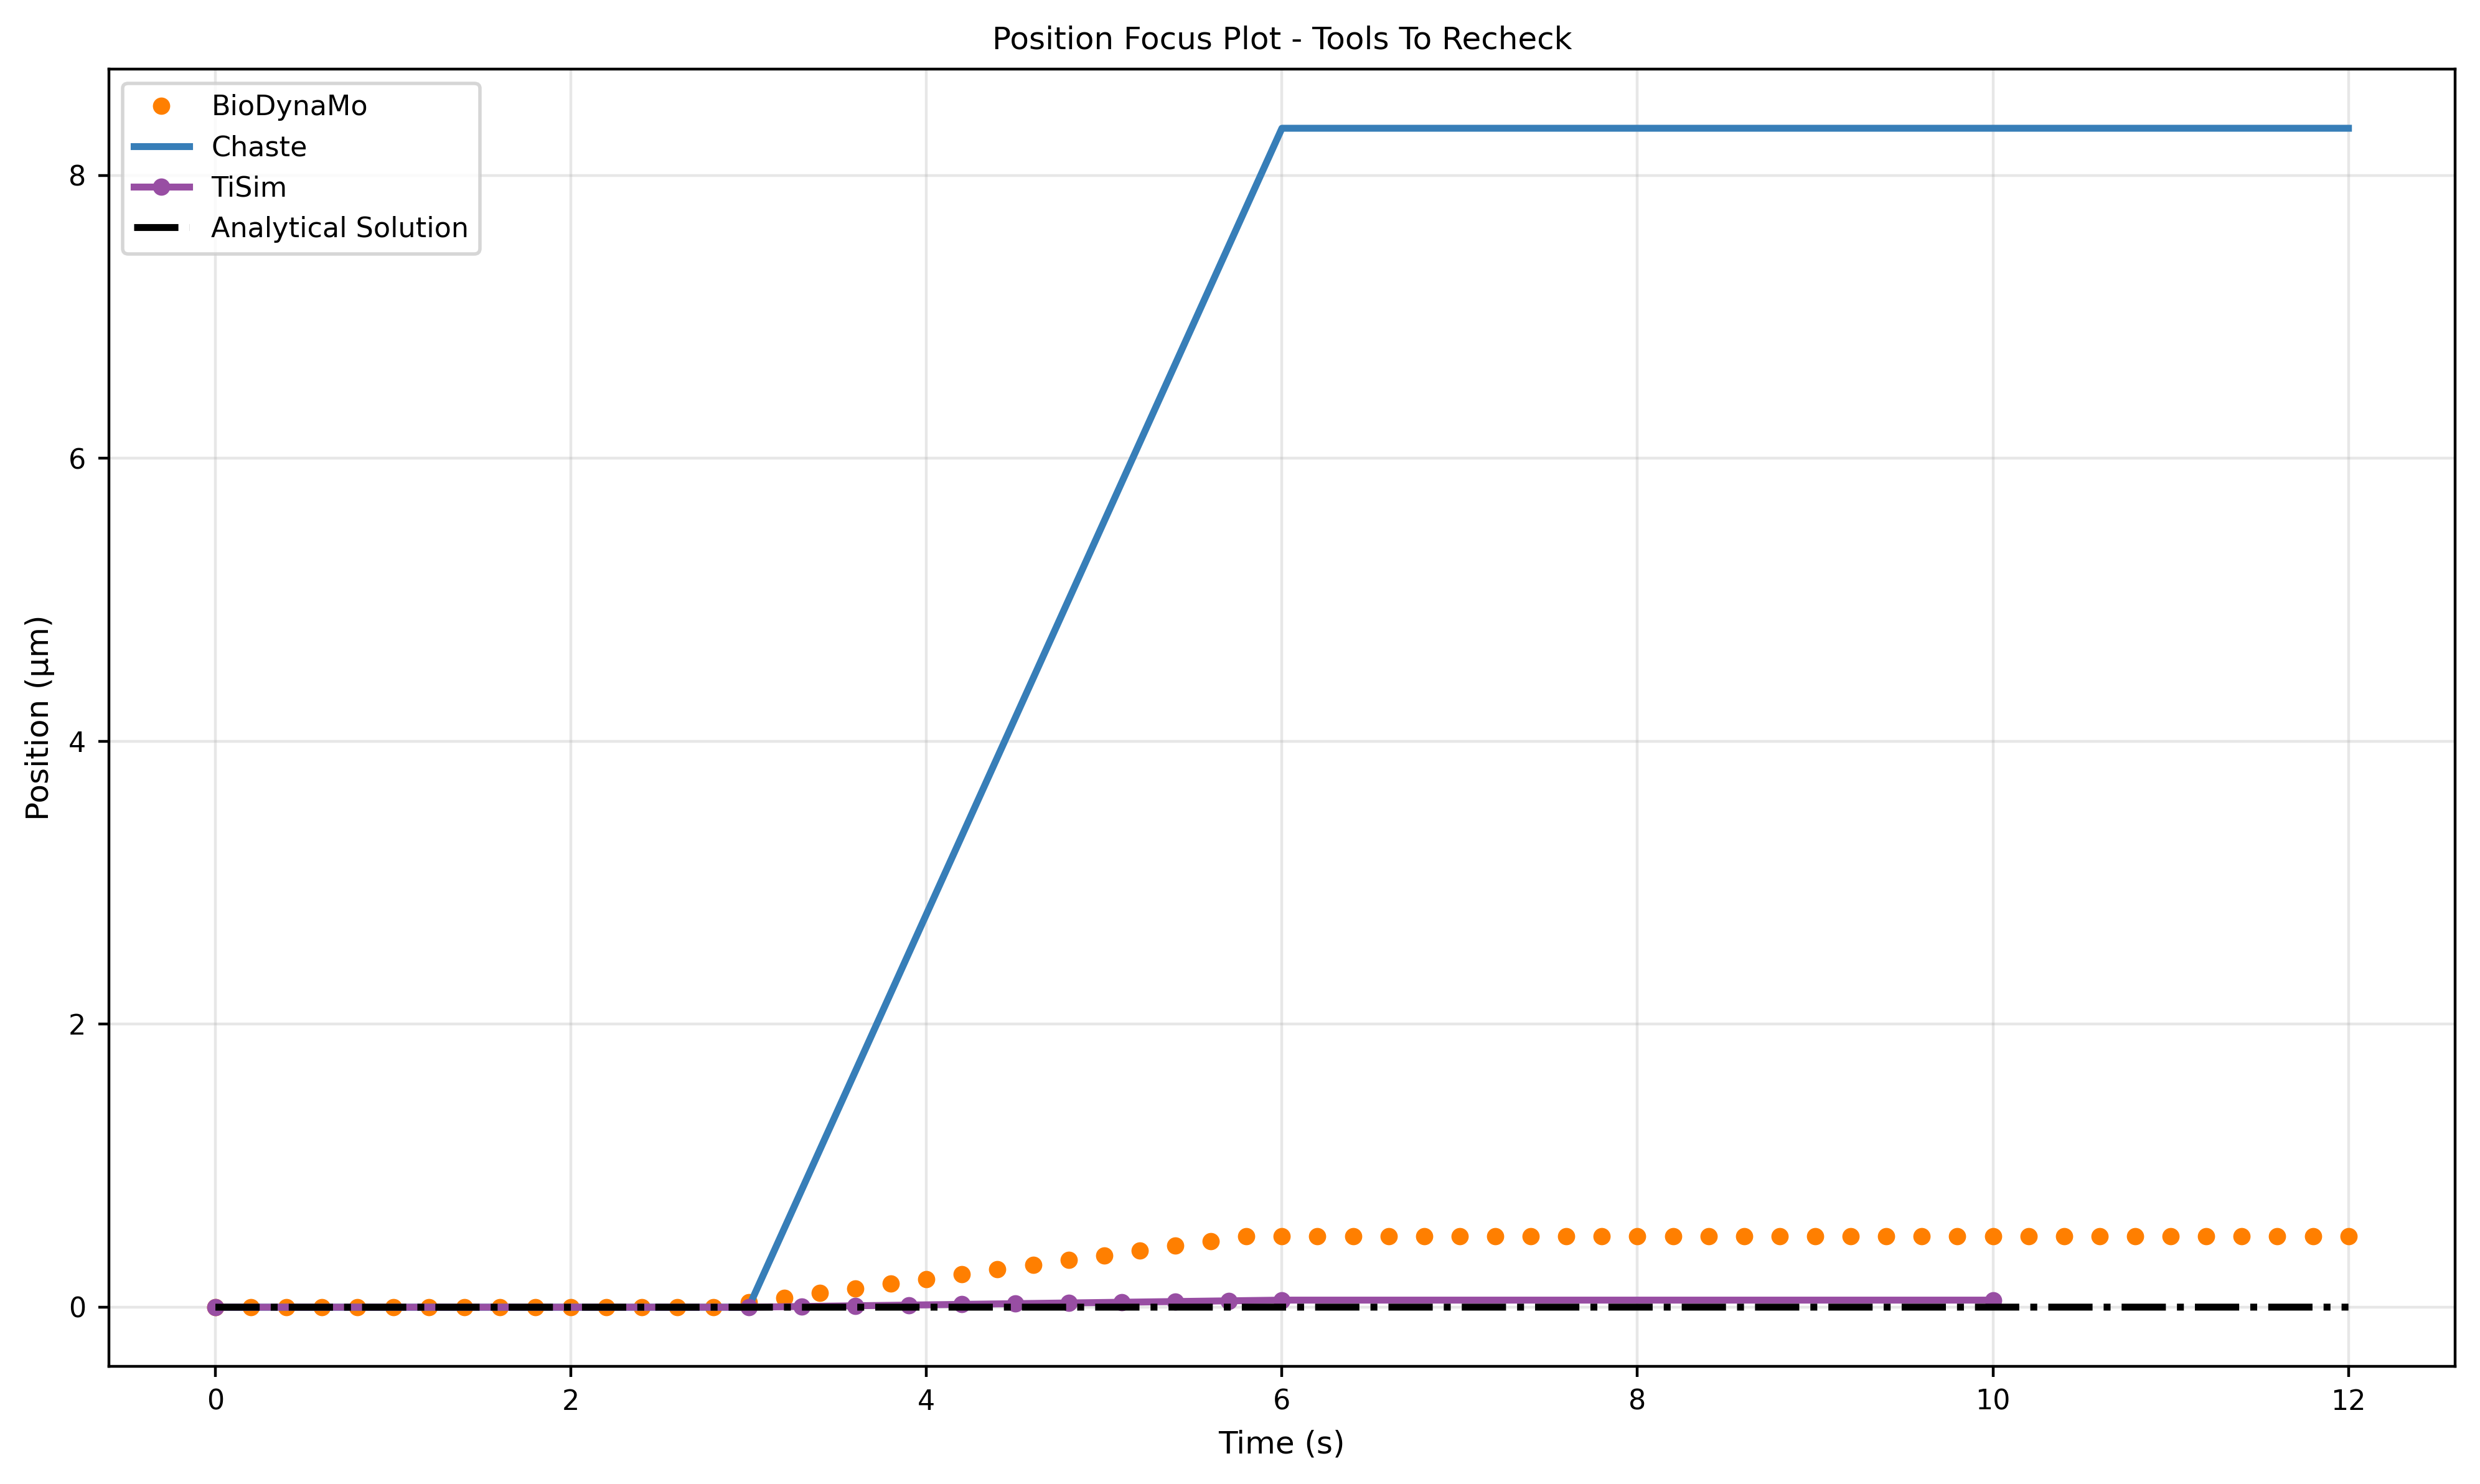

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time, bdm_x, label='BioDynaMo', lw=2, marker='o', linestyle=LINESTYLES['BioDynaMo'], ms=4, color=COLORS['BioDynaMo'])
ax.plot(chaste_time, chaste_x, label='Chaste', lw=2, linestyle=LINESTYLES['Chaste'], color=COLORS['Chaste'])
ax.plot(tisim_time, tisim_x, label='TiSim', lw=2, marker='o', linestyle=LINESTYLES['TiSim'], ms=4, color=COLORS['TiSim'])
ax.plot(analytical_df['time_s'], analytical_df['distance_um'], label='Analytical Solution', lw=2, linestyle=LINESTYLES['Analytical Solution'], color=COLORS['Analytical Solution'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (µm)')
ax.set_title('Position Focus Plot - Tools To Recheck')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Velocity Comparison

This cell plots all tools against the analytical velocity trace after the unit conversions applied in the loading step.

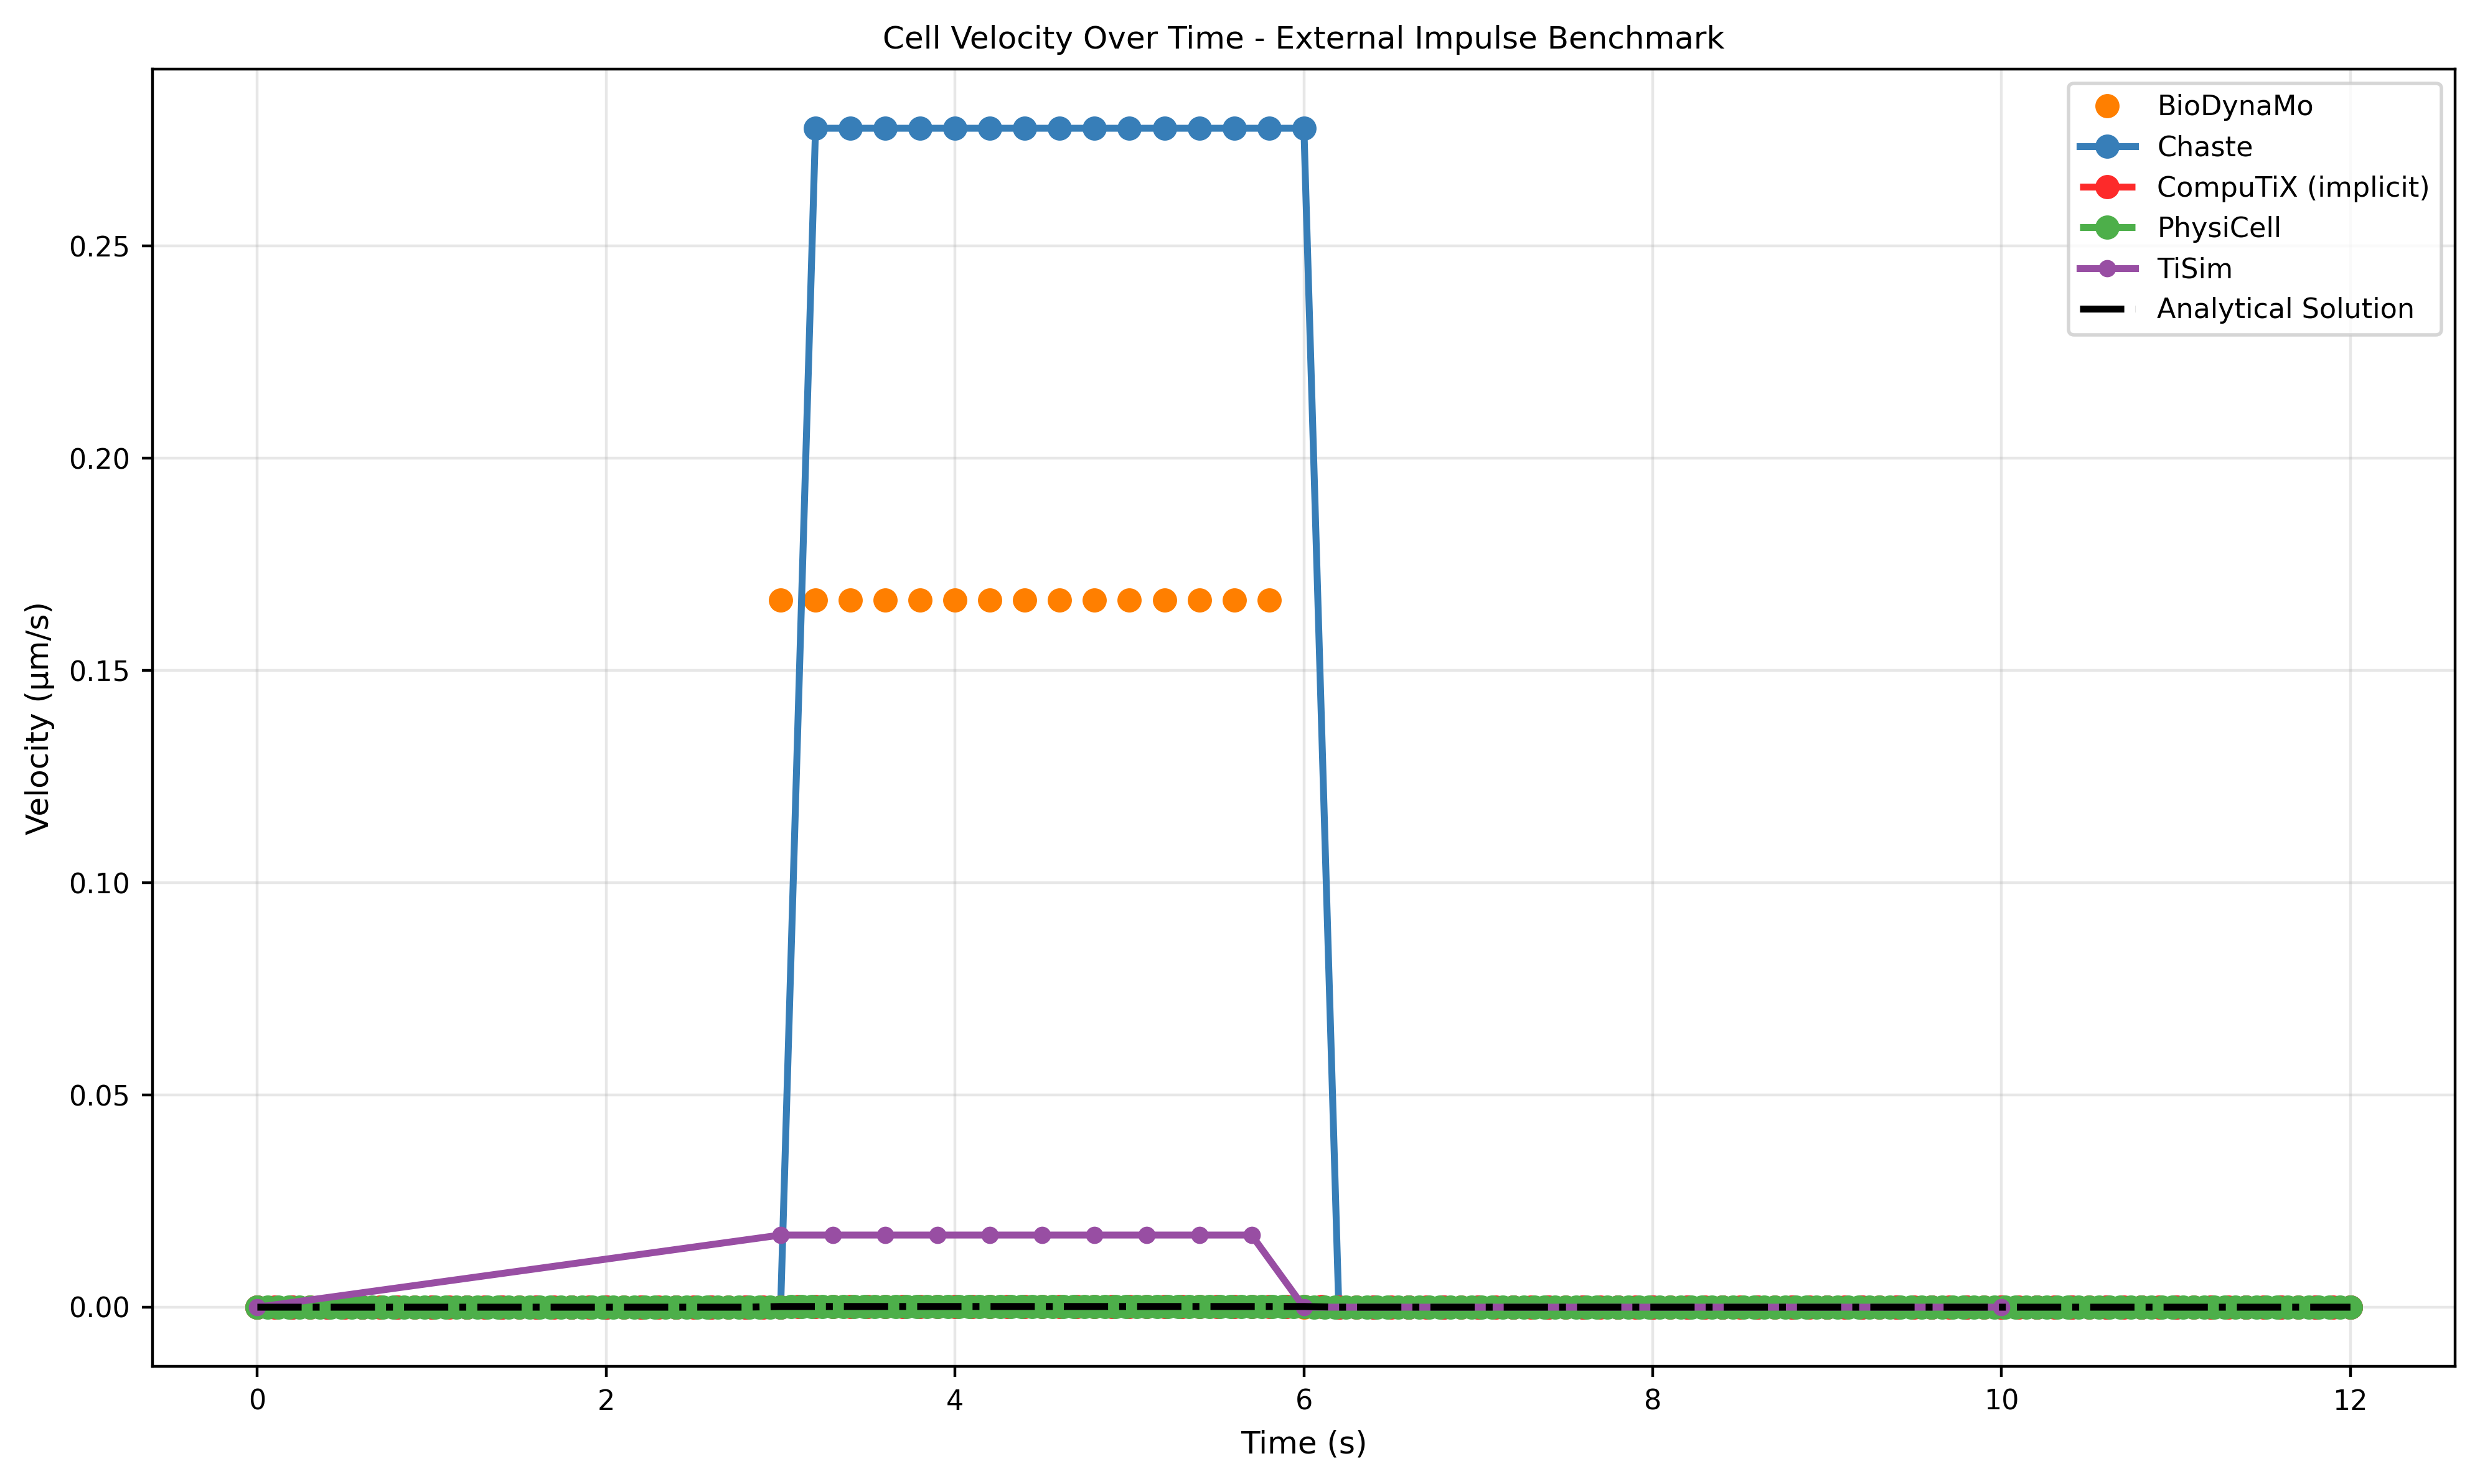

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time, bdm_vx, label='BioDynaMo', lw=2, marker='o', linestyle=LINESTYLES['BioDynaMo'], color=COLORS['BioDynaMo'])
ax.plot(chaste_time, chaste_vx, label='Chaste', lw=2, marker='o', linestyle=LINESTYLES['Chaste'], color=COLORS['Chaste'])
ax.plot(ctix_time, ctix_v_imp, label='CompuTiX (implicit)', lw=2, marker='o', linestyle=LINESTYLES['CompuTiX (implicit)'], color=COLORS['CompuTiX'])
ax.plot(pc_time, pc_vx, label='PhysiCell', lw=2, marker='o', linestyle=LINESTYLES['PhysiCell'], color=COLORS['PhysiCell'])
ax.plot(tisim_time, tisim_vx, label='TiSim', lw=2, marker='o', linestyle=LINESTYLES['TiSim'], ms=4, color=COLORS['TiSim'])
ax.plot(analytical_df['time_s'], analytical_df['velocity_um_per_s'], label='Analytical Solution', lw=2, linestyle=LINESTYLES['Analytical Solution'], color=COLORS['Analytical Solution'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (µm/s)')
ax.set_title('Cell Velocity Over Time - External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mechanics_external_impulse_velocity.png', dpi=150)
plt.show()


## Velocity Focus Plot

This cell isolates the tools whose velocity traces still need validation against the analytical solution.

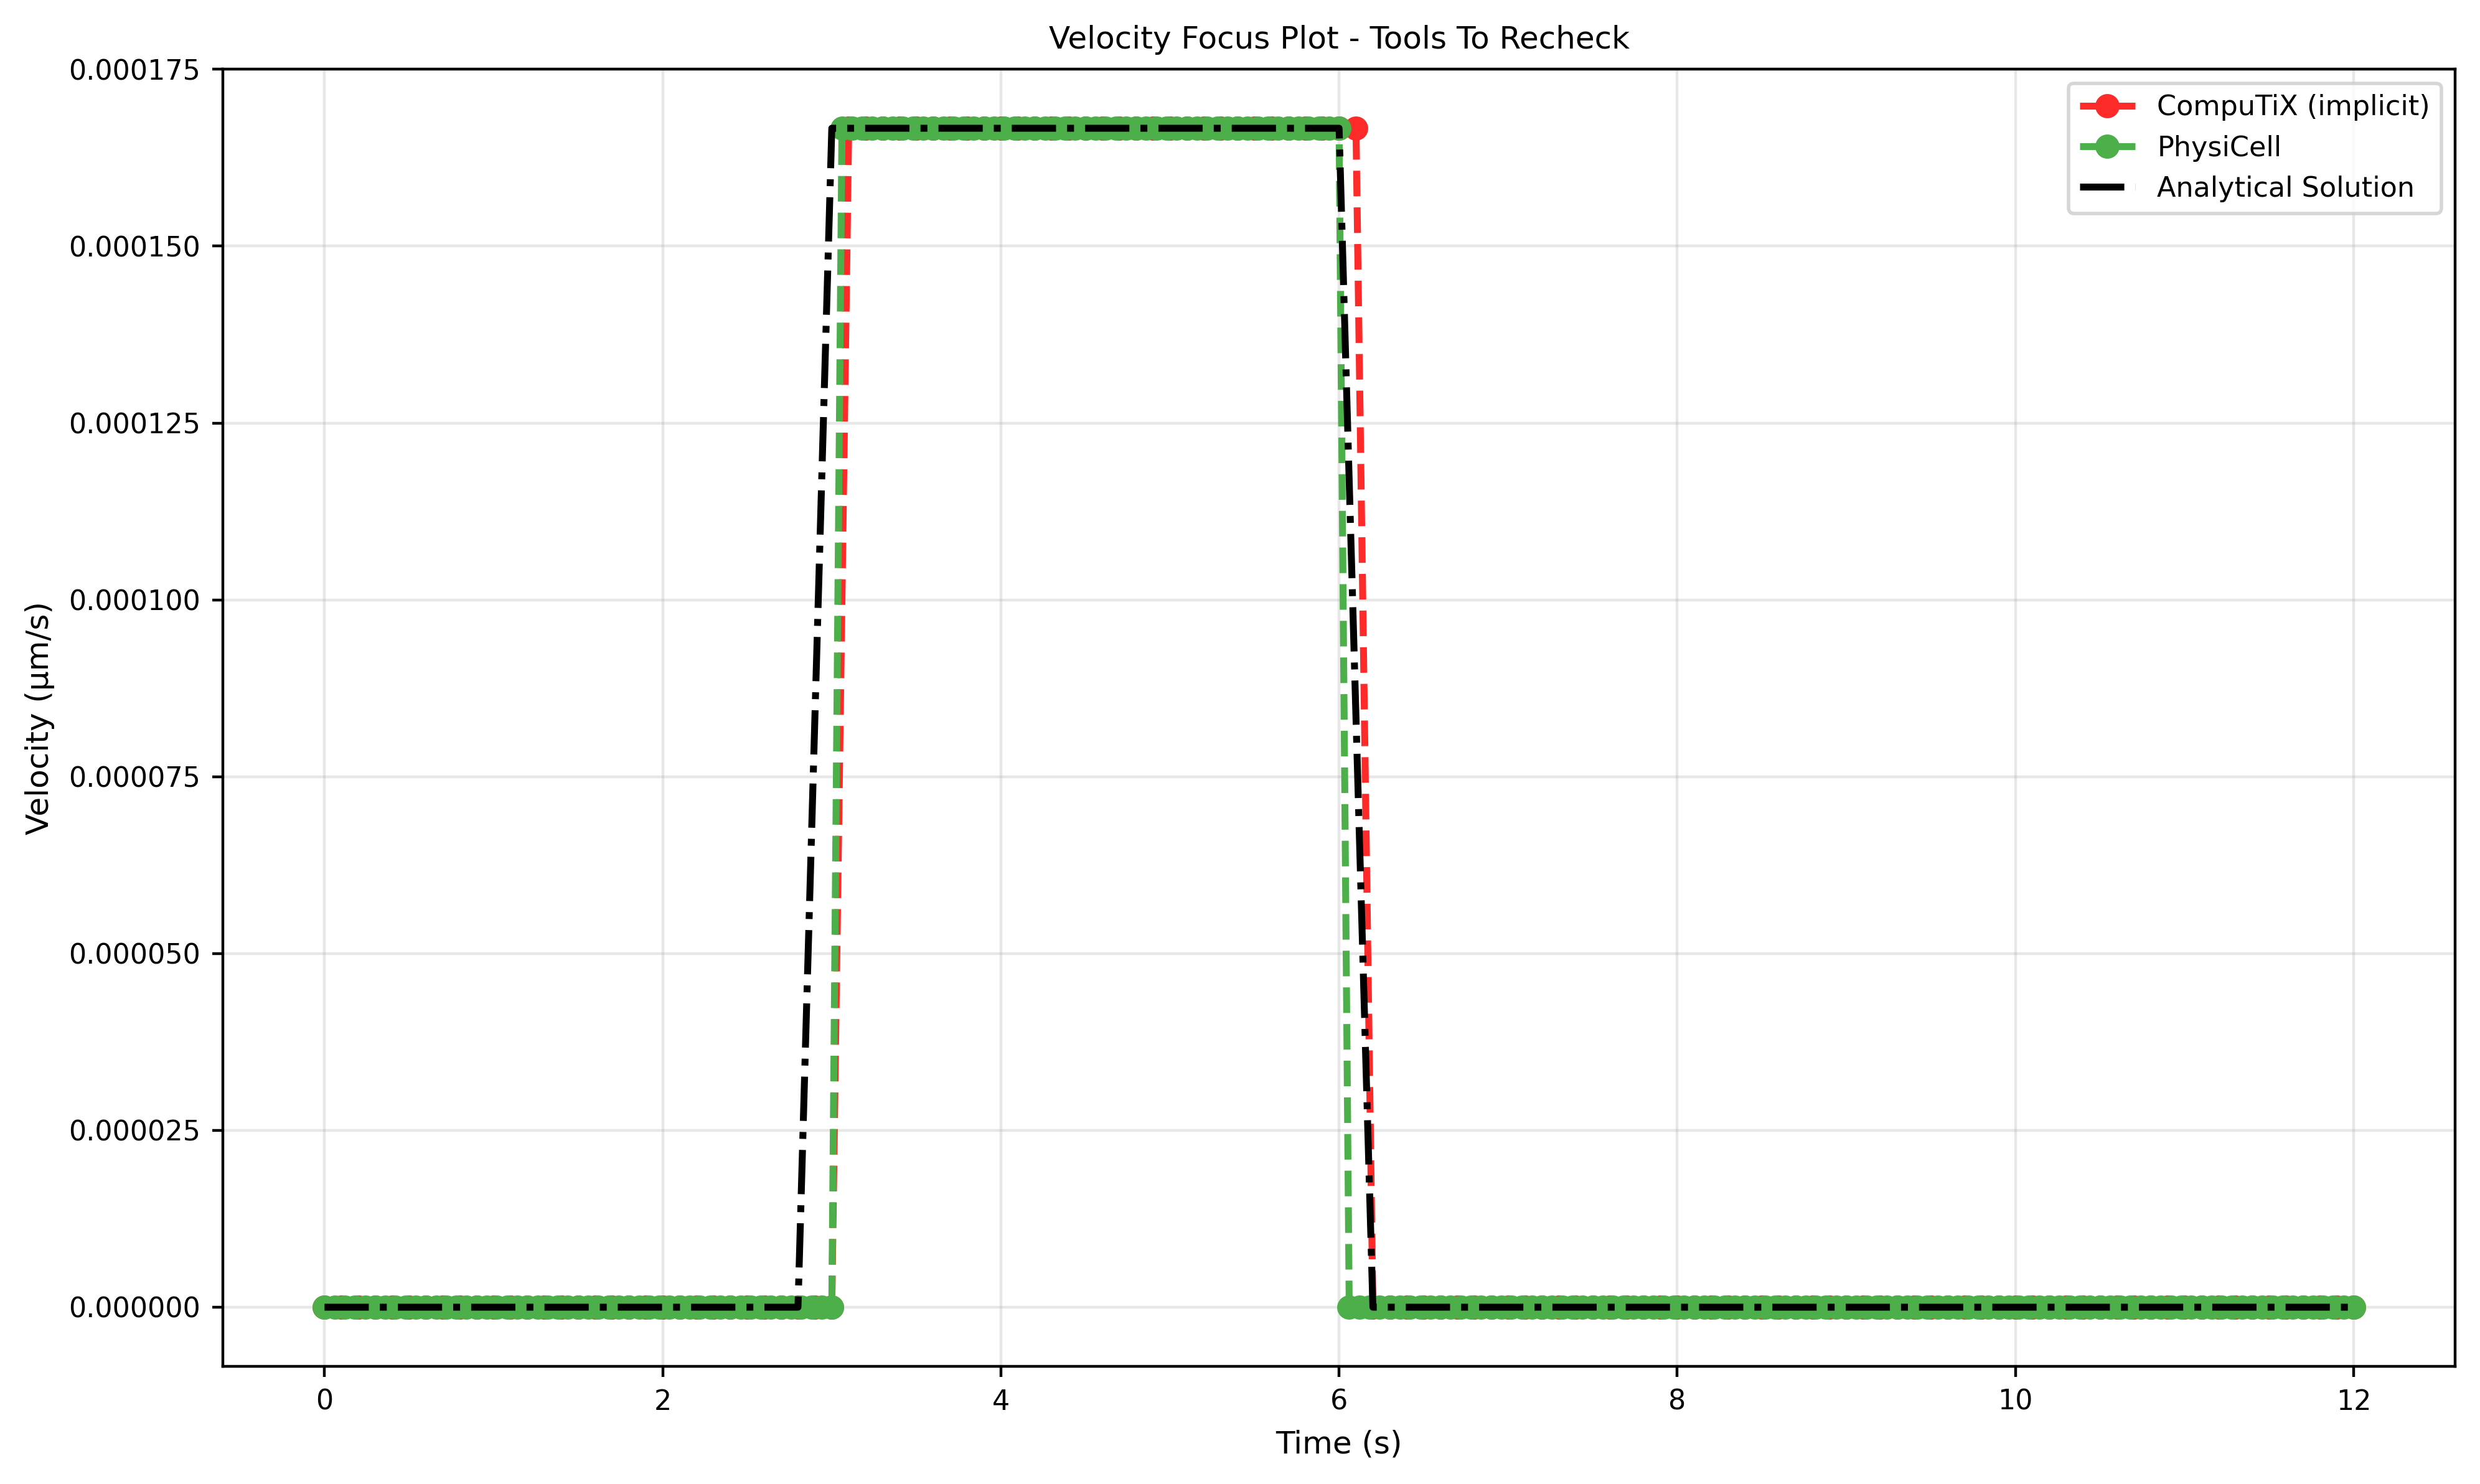

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ctix_time, ctix_v_imp, label='CompuTiX (implicit)', lw=2, marker='o', linestyle=LINESTYLES['CompuTiX (implicit)'], color=COLORS['CompuTiX'])
ax.plot(pc_time, pc_vx, label='PhysiCell', lw=2, marker='o', linestyle=LINESTYLES['PhysiCell'], color=COLORS['PhysiCell'])
ax.plot(analytical_df['time_s'], analytical_df['velocity_um_per_s'], label='Analytical Solution', lw=2, linestyle=LINESTYLES['Analytical Solution'], color=COLORS['Analytical Solution'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (µm/s)')
ax.set_title('Velocity Focus Plot - Tools To Recheck')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Follow-Up Checks

These are the current verification points before treating the benchmark as fully comparable across tools:

1. BioDynaMo: confirm that the reported time resolution is correct and that the applied external force produces the expected velocity profile.
2. Chaste: confirm that the reported time resolution is correct and that the applied external force produces the expected velocity profile.
3. TiSim: provide more time points and confirm the reported time resolution.
4. All tools: document the exact units used for time, distance, velocity, mass or damping terms if relevant, and force so cross-tool comparison is unambiguous.